#**Case Study 02 - Unsupervised Learning**



####Step 1: Import Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

####Step 2: Load Dataset

In [63]:
df= pd.read_csv('/content/adult_dataset.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [64]:
df.shape

(48842, 15)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [66]:
df.duplicated().sum()

np.int64(16)

In [67]:
df.drop_duplicates(inplace=True)

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46384.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,46384.000000
mean,38.681528,1.896605e+05,10.078278,1079.421230,87.530988,40.451039
std,13.951072,1.056025e+05,2.570759,7453.214369,403.067466,12.645956
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [70]:
# replace ? as nan
df.replace(" ?", np.nan, inplace=True)
df.replace("?", np.nan, inplace=True)

####Step 3: Check Missing Values

In [71]:
df.isna().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [72]:
round(df.isna().mean()*100,2)
# % of missing values

,0
age,5.00
workclass,10.50
fnlwgt,0.00
education,0.00
education-num,0.00
marital-status,0.00
occupation,10.48
relationship,0.00
race,0.00
sex,0.00


####Step 4: Fill Missing Values

In [73]:
# fill numerical with median

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_94532/2198040727.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [74]:
#fill categorical with mode

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_94532/2845975939.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [75]:
df.isna().sum()  # no missing values

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


####Step 5: Drop Income Column

In [76]:
df.drop("income", axis=1, inplace=True)

####Step 6: EDA

In [77]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States
48838,64.0,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40.0,United-States
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States


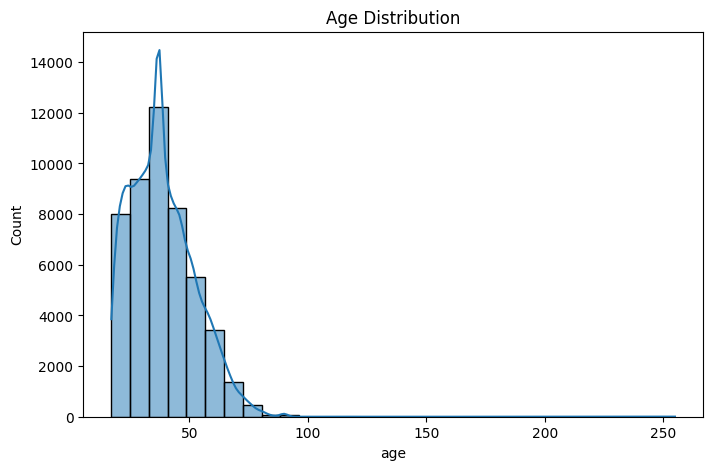

In [78]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")  #highly positively skewd
plt.show()

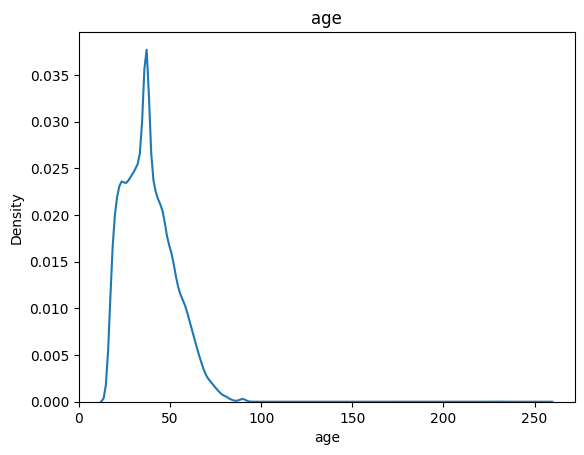

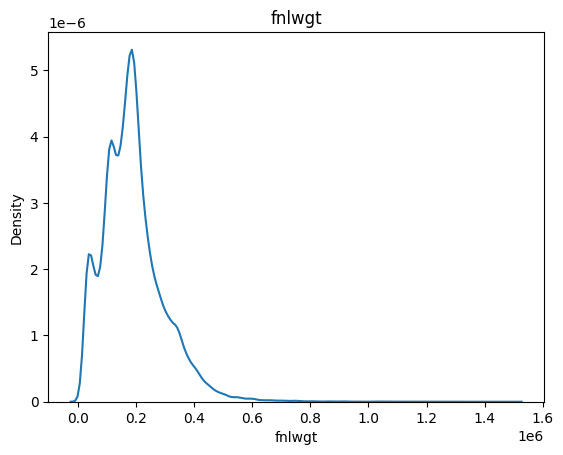

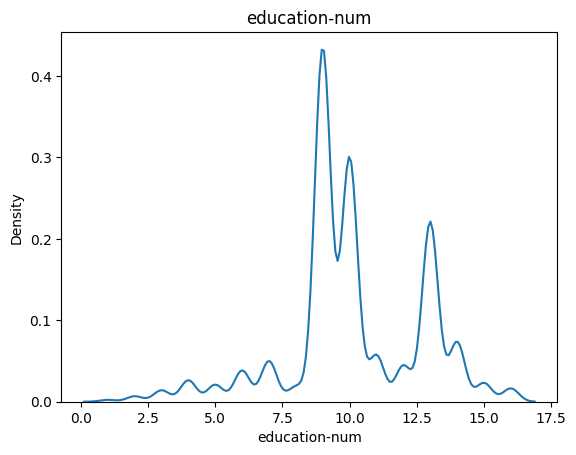

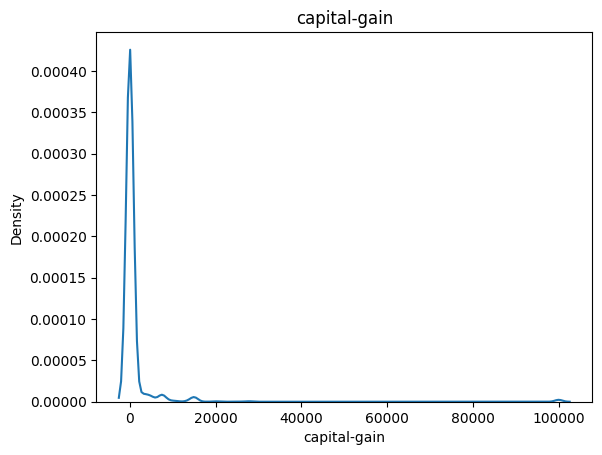

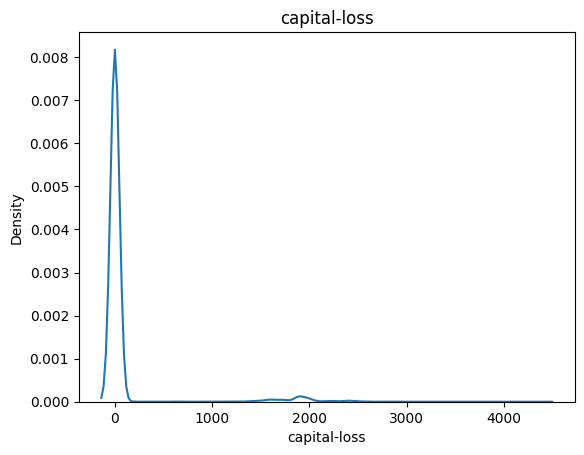

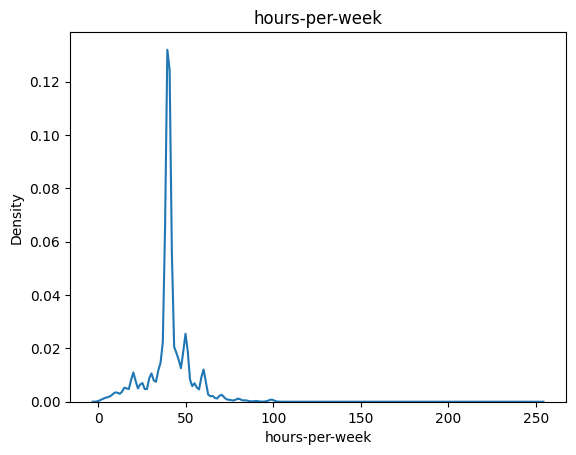

In [79]:
for i in df.select_dtypes('number').columns:
    sns.kdeplot(df[i])
    plt.title(i)
    plt.show()

1.0178261301576765


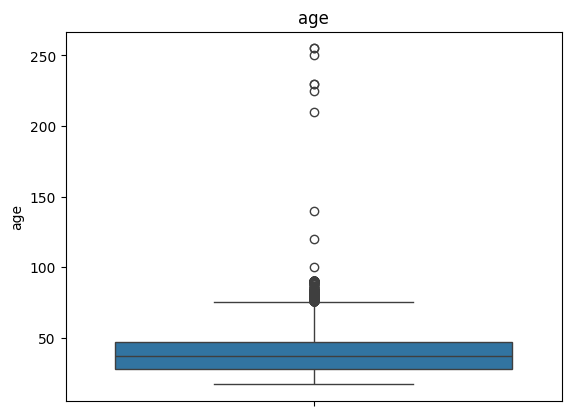

1.439357421923382


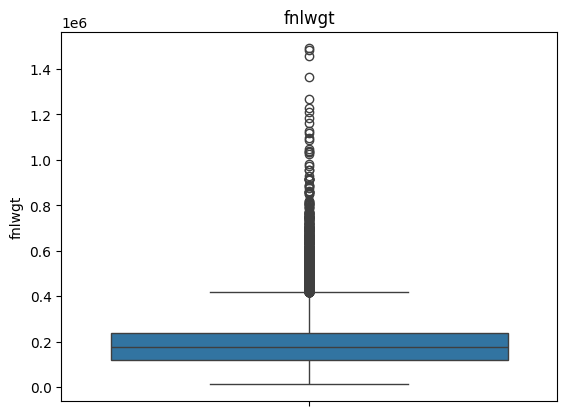

-0.3159699164222054


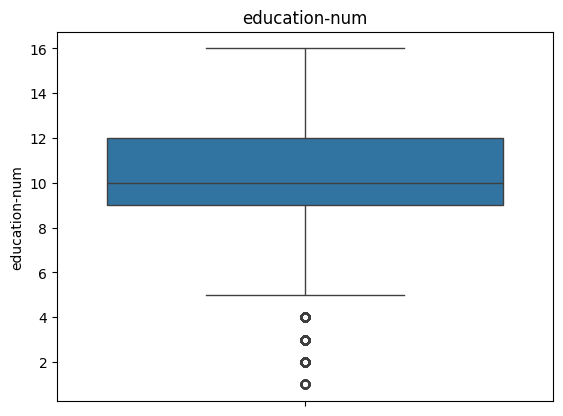

11.892691923804659


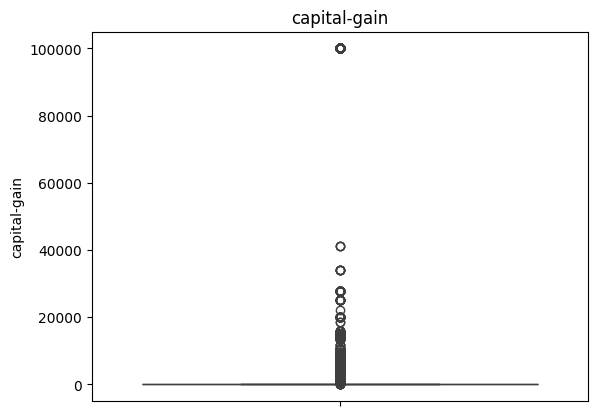

4.568956145690445


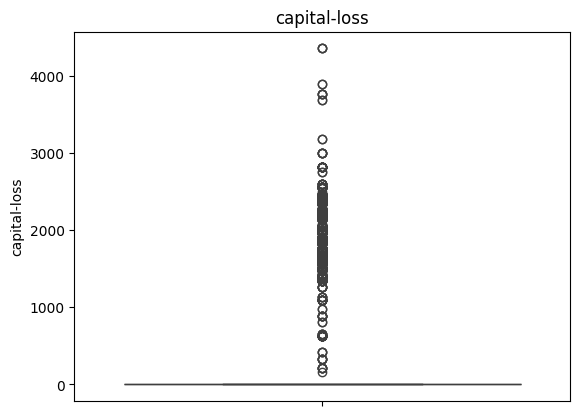

0.8129373452995078


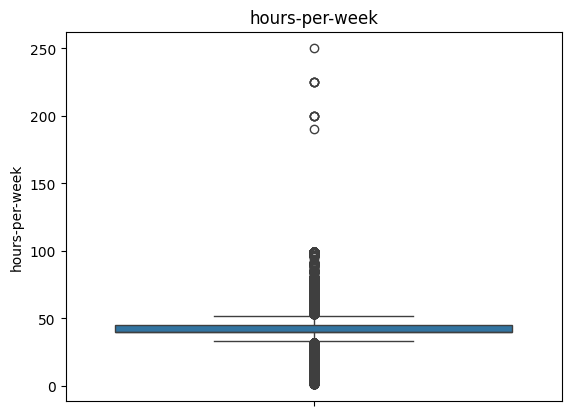

In [80]:
for i in df.select_dtypes('number').columns:
    sns.boxplot(df[i])
    plt.title(i)
    print(df[i].skew())
    plt.show()

In [81]:
# all columns are skewd and have outliers

####outlier handling

In [82]:
df.select_dtypes('number').skew().sort_values(ascending=False)

,0
capital-gain,11.892692
capital-loss,4.568956
fnlwgt,1.439357
age,1.017826
hours-per-week,0.812937
education-num,-0.315970


In [83]:
def outlier_cap(df,columns):
  for i in columns:
    q1= df[i].quantile(.25)
    q3=df[i].quantile(.75)
    iqr=q3-q1
    lower_bound= q1-1.5*iqr
    upper_bound= q3+1.5*iqr

    df.loc[df[i]<lower_bound,i]=lower_bound
    df.loc[df[i]>upper_bound,i]=upper_bound
  return df,columns

In [84]:
outlier_cap(df,['age','hours-per-week'])

(        age         workclass  fnlwgt  education  education-num  \
 0      39.0         State-gov   77516  Bachelors             13   
 1      50.0  Self-emp-not-inc   83311  Bachelors             13   
 2      38.0           Private  215646    HS-grad              9   
 3      53.0           Private  234721       11th              7   
 4      28.0           Private  338409  Bachelors             13   
 ...     ...               ...     ...        ...            ...   
 48837  39.0           Private  215419  Bachelors             13   
 48838  64.0           Private  321403    HS-grad              9   
 48839  38.0           Private  374983  Bachelors             13   
 48840  44.0           Private   83891  Bachelors             13   
 48841  35.0      Self-emp-inc  182148  Bachelors             13   
 
            marital-status         occupation    relationship  \
 0           Never-married       Adm-clerical   Not-in-family   
 1      Married-civ-spouse    Exec-managerial       

0.5300995463815201


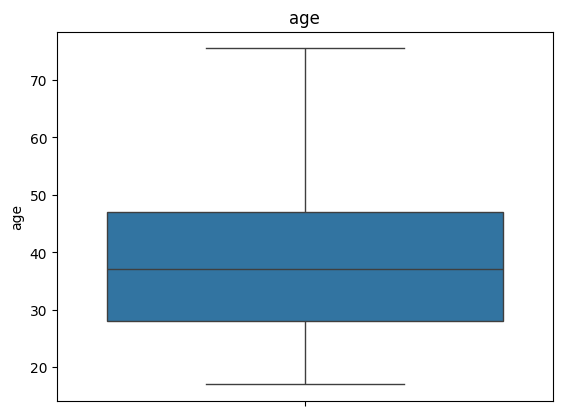

1.439357421923382


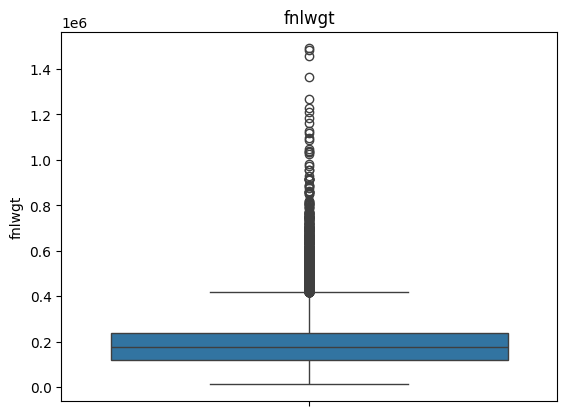

-0.3159699164222054


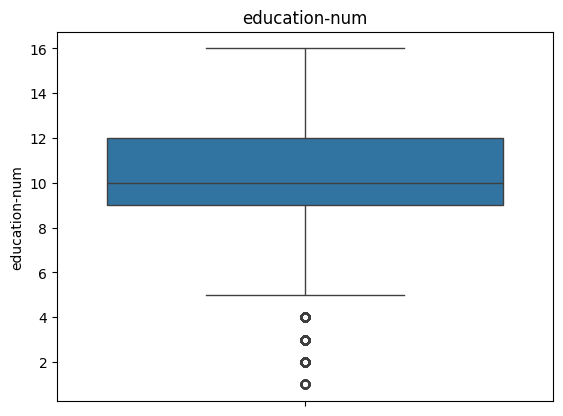

11.892691923804659


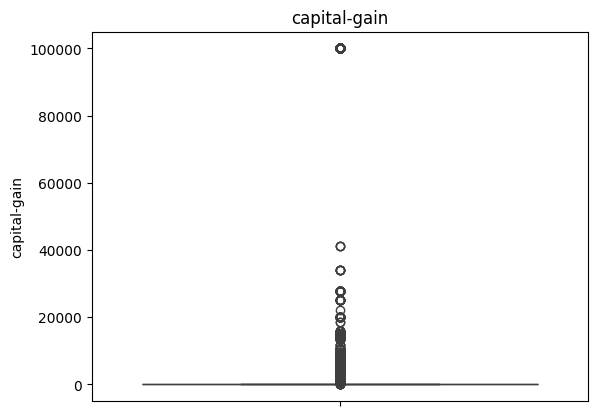

4.568956145690445


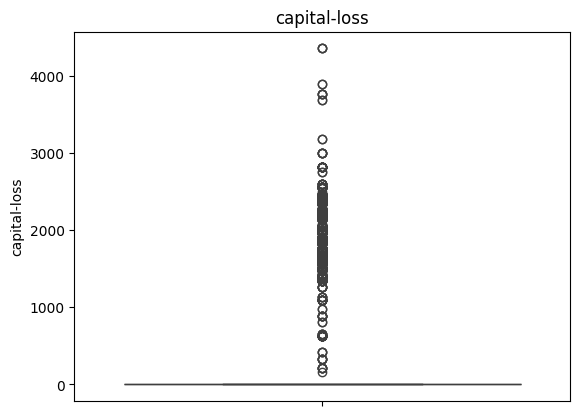

0.48041518017196627


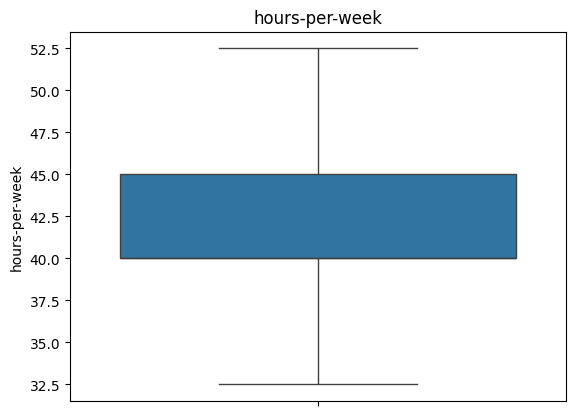

In [85]:
for i in df.select_dtypes('number').columns:
    sns.boxplot(df[i])
    plt.title(i)
    print(df[i].skew())
    plt.show()

In [86]:
# don't do capping to other columns bcoz they are genuine outliers if we do it make change the orginal df pattern

0.5300995463815201


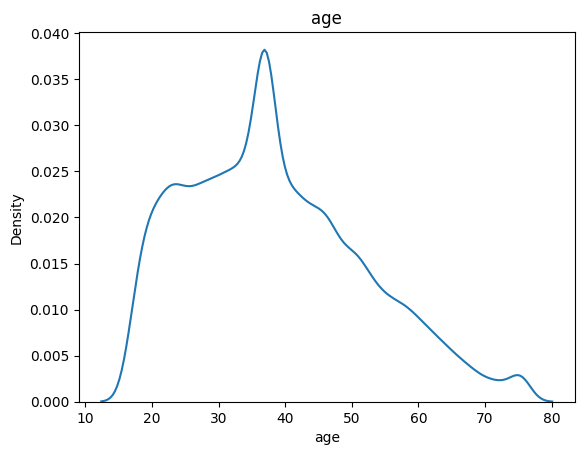

1.439357421923382


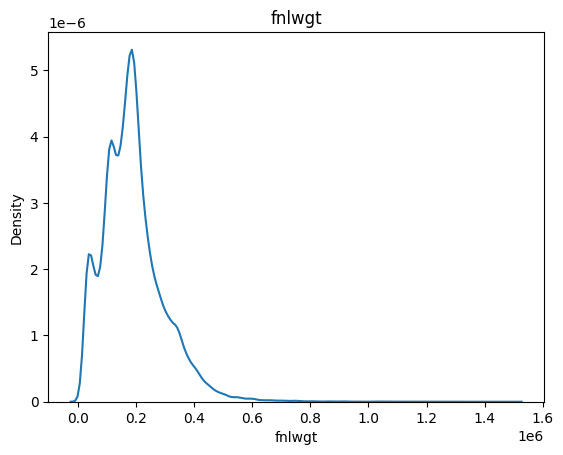

-0.3159699164222054


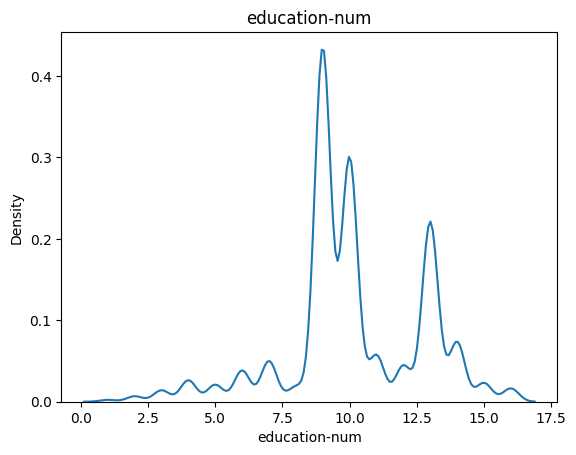

11.892691923804659


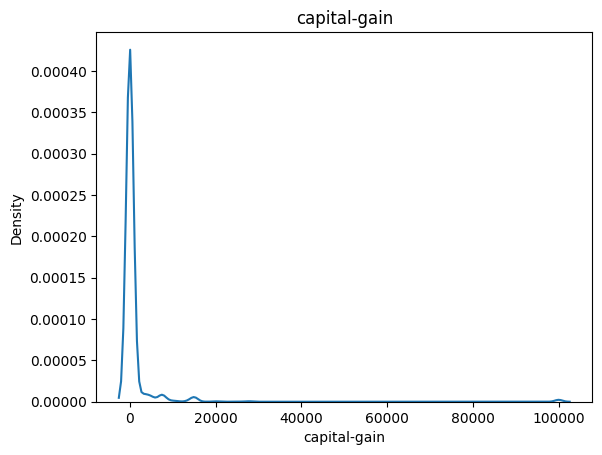

4.568956145690445


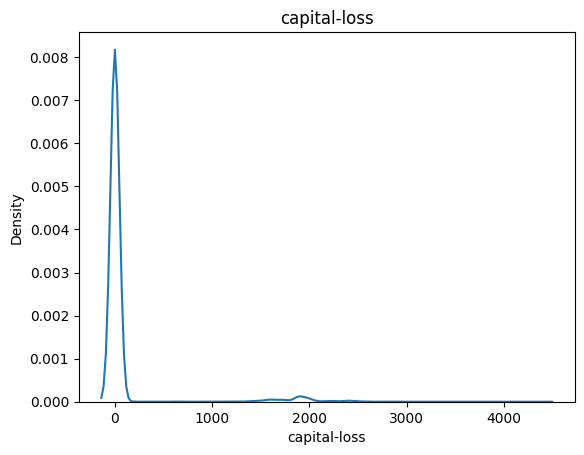

0.48041518017196627


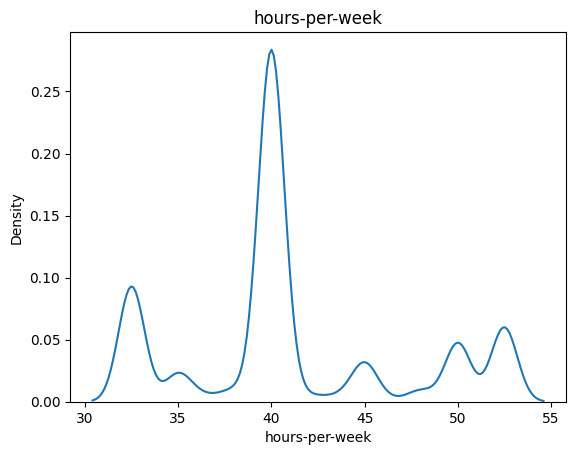

In [87]:
for i in df.select_dtypes('number').columns:
    sns.kdeplot(df[i])
    plt.title(i)
    print(df[i].skew())
    plt.show()

In [88]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48826.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,48826.000000
mean,38.533927,1.896605e+05,10.078278,1079.421230,87.530988,41.130514
std,13.270067,1.056025e+05,2.570759,7453.214369,403.067466,6.033641
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,32.500000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,75.500000,1.490400e+06,16.000000,99999.000000,4356.000000,52.500000


#### log transform

In [89]:
# 1. Log transform skewed numeric columns
for i in df[['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']]:
    df[i] = np.log1p(df[i])


-0.1428406659761609


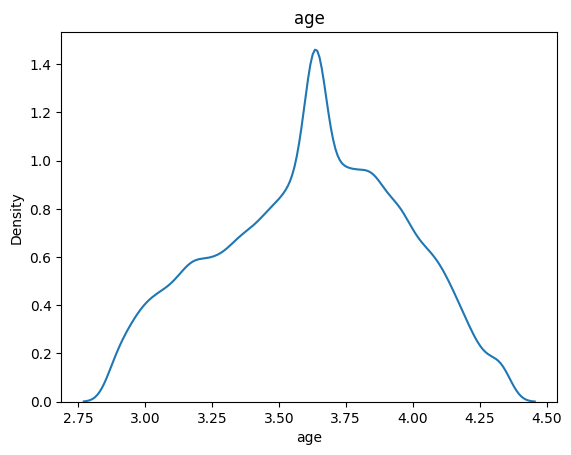

-0.8363373035268203


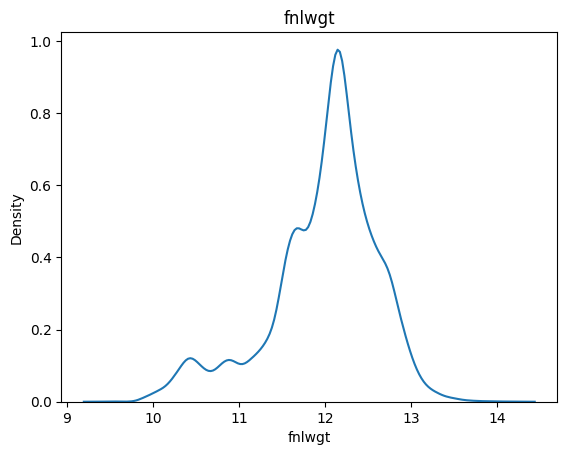

-1.7358201900105714


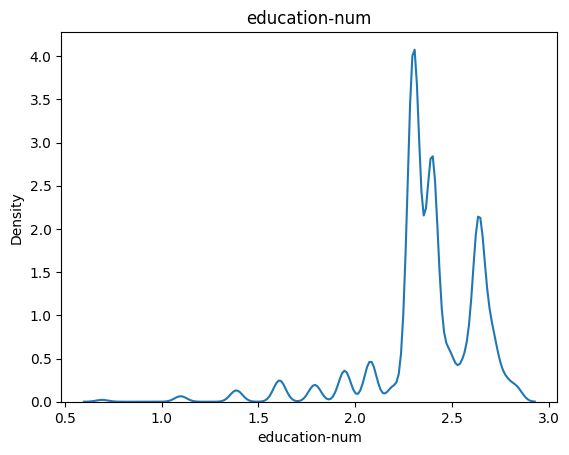

3.112972019493486


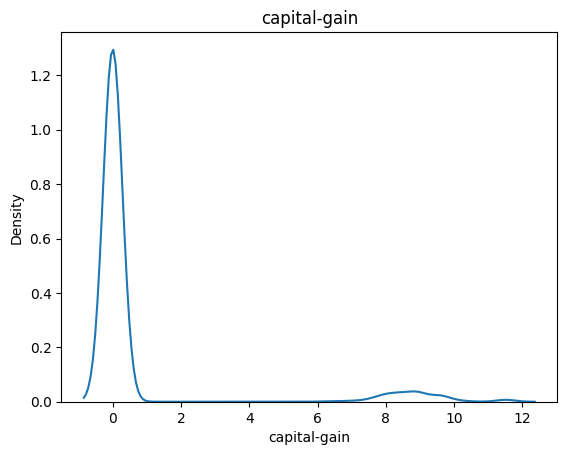

4.302144302380041


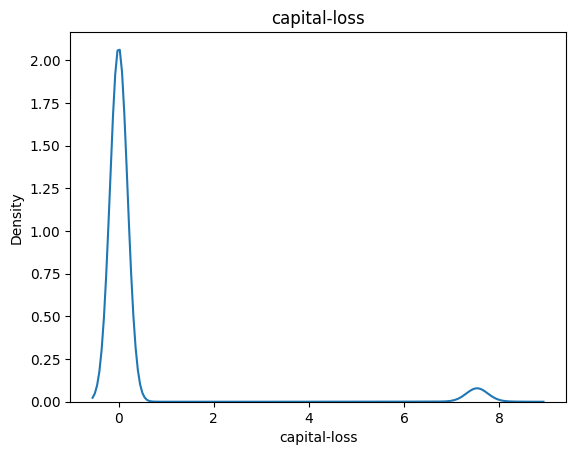

0.20237356915354965


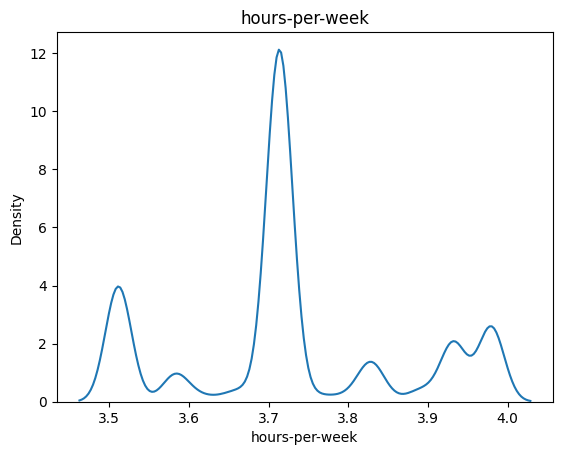

In [90]:
for i in df.select_dtypes('number').columns:
    sns.kdeplot(df[i])
    plt.title(i)
    print(df[i].skew())
    plt.show()

-0.1428406659761609


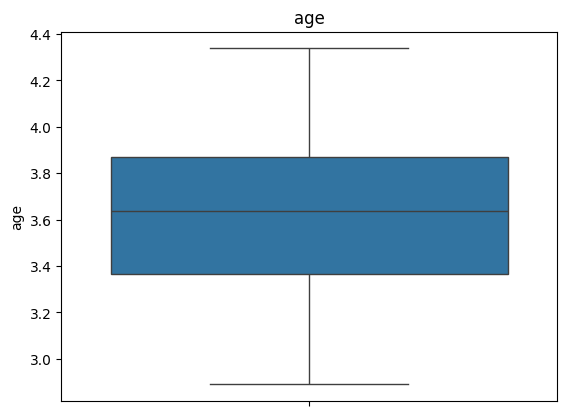

-0.8363373035268203


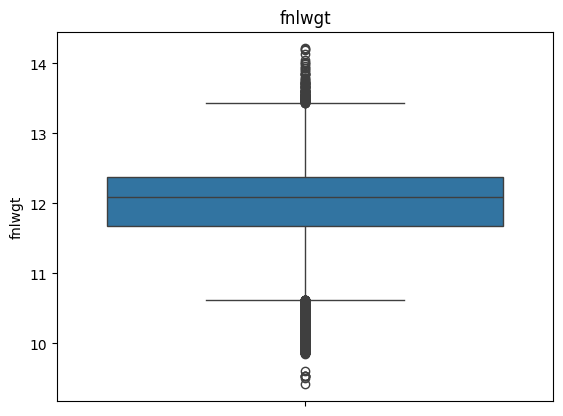

-1.7358201900105714


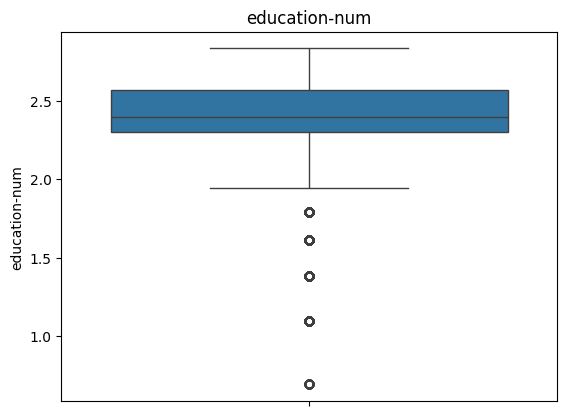

3.112972019493486


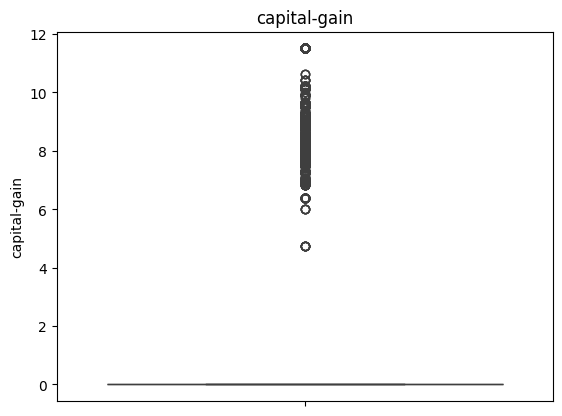

4.302144302380041


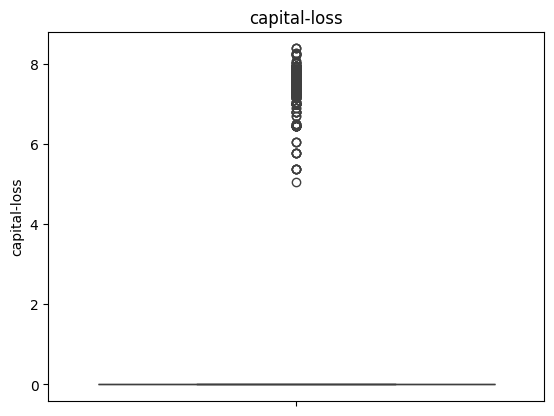

0.20237356915354965


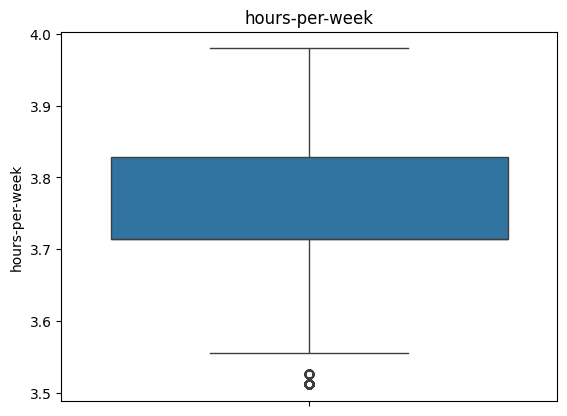

In [91]:
for i in df.select_dtypes('number').columns:
    sns.boxplot(df[i])
    plt.title(i)
    print(df[i].skew())
    plt.show()

####encoding

In [92]:
df.select_dtypes('object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba
...,...,...,...,...,...,...,...,...
48837,Private,Bachelors,Divorced,Prof-specialty,Not-in-family,White,Female,United-States
48838,Private,HS-grad,Widowed,Prof-specialty,Other-relative,Black,Male,United-States
48839,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
48840,Private,Bachelors,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,United-States


In [93]:
df['native-country'].value_counts()

,count
native-country,
United-States,44869
Mexico,906
Philippines,282
Germany,194
Puerto-Rico,175
Canada,170
El-Salvador,147
India,143
Cuba,132


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48826 non-null  float64
 1   workclass       48826 non-null  object 
 2   fnlwgt          48826 non-null  float64
 3   education       48826 non-null  object 
 4   education-num   48826 non-null  float64
 5   marital-status  48826 non-null  object 
 6   occupation      48826 non-null  object 
 7   relationship    48826 non-null  object 
 8   race            48826 non-null  object 
 9   sex             48826 non-null  object 
 10  capital-gain    48826 non-null  float64
 11  capital-loss    48826 non-null  float64
 12  hours-per-week  48826 non-null  float64
 13  native-country  48826 non-null  object 
dtypes: float64(6), object(8)
memory usage: 5.6+ MB


In [95]:
# OHE

# List of columns to one-hot encode
ohe_columns = ['workclass','marital-status','relationship','race']

# Create dummy variables for all specified columns
dummy_cols = pd.get_dummies(df[ohe_columns], dtype=int, drop_first=True)

# Drop the original categorical columns from df
df = df.drop(columns=ohe_columns)

# Concatenate the original DataFrame with the new dummy variables
df = pd.concat([df, dummy_cols], axis=1)

df

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,3.688879,11.258253,Bachelors,2.639057,Adm-clerical,Male,7.684784,0.0,3.713572,United-States,...,0,1,0,0,0,0,0,0,0,1
1,3.931826,11.330348,Bachelors,2.639057,Exec-managerial,Male,0.000000,0.0,3.511545,United-States,...,0,0,0,0,0,0,0,0,0,1
2,3.663562,12.281398,HS-grad,2.302585,Handlers-cleaners,Male,0.000000,0.0,3.713572,United-States,...,0,1,0,0,0,0,0,0,0,1
3,3.988984,12.366157,11th,2.079442,Handlers-cleaners,Male,0.000000,0.0,3.713572,United-States,...,0,0,0,0,0,0,0,1,0,0
4,3.367296,12.732013,Bachelors,2.639057,Prof-specialty,Female,0.000000,0.0,3.713572,Cuba,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,3.688879,12.280345,Bachelors,2.639057,Prof-specialty,Female,0.000000,0.0,3.610918,United-States,...,0,1,0,0,0,0,0,0,0,1
48838,4.174387,12.680454,HS-grad,2.302585,Prof-specialty,Male,0.000000,0.0,3.713572,United-States,...,1,0,1,0,0,0,0,1,0,0
48839,3.663562,12.834639,Bachelors,2.639057,Prof-specialty,Male,0.000000,0.0,3.931826,United-States,...,0,0,0,0,0,0,0,0,0,1
48840,3.806662,11.337286,Bachelors,2.639057,Adm-clerical,Male,8.604471,0.0,3.713572,United-States,...,0,0,0,1,0,0,1,0,0,0


In [96]:
#ordinal
from sklearn.preprocessing import OrdinalEncoder
ordinal = OrdinalEncoder(categories=[['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th','HS-grad','Some-college','Assoc-voc','Assoc-acdm','Bachelors','Masters','Prof-school','Doctorate']])
# Apply OrdinalEncoder to the 'education' column
df['education']= ordinal.fit_transform(df[['education']])
df

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,3.688879,11.258253,12.0,2.639057,Adm-clerical,Male,7.684784,0.0,3.713572,United-States,...,0,1,0,0,0,0,0,0,0,1
1,3.931826,11.330348,12.0,2.639057,Exec-managerial,Male,0.000000,0.0,3.511545,United-States,...,0,0,0,0,0,0,0,0,0,1
2,3.663562,12.281398,8.0,2.302585,Handlers-cleaners,Male,0.000000,0.0,3.713572,United-States,...,0,1,0,0,0,0,0,0,0,1
3,3.988984,12.366157,6.0,2.079442,Handlers-cleaners,Male,0.000000,0.0,3.713572,United-States,...,0,0,0,0,0,0,0,1,0,0
4,3.367296,12.732013,12.0,2.639057,Prof-specialty,Female,0.000000,0.0,3.713572,Cuba,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,3.688879,12.280345,12.0,2.639057,Prof-specialty,Female,0.000000,0.0,3.610918,United-States,...,0,1,0,0,0,0,0,0,0,1
48838,4.174387,12.680454,8.0,2.302585,Prof-specialty,Male,0.000000,0.0,3.713572,United-States,...,1,0,1,0,0,0,0,1,0,0
48839,3.663562,12.834639,12.0,2.639057,Prof-specialty,Male,0.000000,0.0,3.931826,United-States,...,0,0,0,0,0,0,0,0,0,1
48840,3.806662,11.337286,12.0,2.639057,Adm-clerical,Male,8.604471,0.0,3.713572,United-States,...,0,0,0,1,0,0,1,0,0,0


In [97]:
#label
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
# Apply LabelEncoder directly to the 'sex' column
df['sex']= le.fit_transform(df['sex'])
df

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,3.688879,11.258253,12.0,2.639057,Adm-clerical,1,7.684784,0.0,3.713572,United-States,...,0,1,0,0,0,0,0,0,0,1
1,3.931826,11.330348,12.0,2.639057,Exec-managerial,1,0.000000,0.0,3.511545,United-States,...,0,0,0,0,0,0,0,0,0,1
2,3.663562,12.281398,8.0,2.302585,Handlers-cleaners,1,0.000000,0.0,3.713572,United-States,...,0,1,0,0,0,0,0,0,0,1
3,3.988984,12.366157,6.0,2.079442,Handlers-cleaners,1,0.000000,0.0,3.713572,United-States,...,0,0,0,0,0,0,0,1,0,0
4,3.367296,12.732013,12.0,2.639057,Prof-specialty,0,0.000000,0.0,3.713572,Cuba,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,3.688879,12.280345,12.0,2.639057,Prof-specialty,0,0.000000,0.0,3.610918,United-States,...,0,1,0,0,0,0,0,0,0,1
48838,4.174387,12.680454,8.0,2.302585,Prof-specialty,1,0.000000,0.0,3.713572,United-States,...,1,0,1,0,0,0,0,1,0,0
48839,3.663562,12.834639,12.0,2.639057,Prof-specialty,1,0.000000,0.0,3.931826,United-States,...,0,0,0,0,0,0,0,0,0,1
48840,3.806662,11.337286,12.0,2.639057,Adm-clerical,1,8.604471,0.0,3.713572,United-States,...,0,0,0,1,0,0,1,0,0,0


In [98]:
# frequency encoding
columns_to_freq_encode = ['native-country', 'occupation']
for col_name in columns_to_freq_encode:
    freq = df[col_name].value_counts()
    df[col_name] = df[col_name].map(freq)


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 32 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48826 non-null  float64
 1   fnlwgt                                48826 non-null  float64
 2   education                             48826 non-null  float64
 3   education-num                         48826 non-null  float64
 4   occupation                            48826 non-null  int64  
 5   sex                                   48826 non-null  int64  
 6   capital-gain                          48826 non-null  float64
 7   capital-loss                          48826 non-null  float64
 8   hours-per-week                        48826 non-null  float64
 9   native-country                        48826 non-null  int64  
 10  workclass_Local-gov                   48826 non-null  int64  
 11  workclass_Never-work

####scale

In [100]:
df

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,3.688879,11.258253,12.0,2.639057,5328,1,7.684784,0.0,3.713572,44869,...,0,1,0,0,0,0,0,0,0,1
1,3.931826,11.330348,12.0,2.639057,5770,1,0.000000,0.0,3.511545,44869,...,0,0,0,0,0,0,0,0,0,1
2,3.663562,12.281398,8.0,2.302585,1976,1,0.000000,0.0,3.713572,44869,...,0,1,0,0,0,0,0,0,0,1
3,3.988984,12.366157,6.0,2.079442,1976,1,0.000000,0.0,3.713572,44869,...,0,0,0,0,0,0,0,1,0,0
4,3.367296,12.732013,12.0,2.639057,10966,0,0.000000,0.0,3.713572,132,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,3.688879,12.280345,12.0,2.639057,10966,0,0.000000,0.0,3.610918,44869,...,0,1,0,0,0,0,0,0,0,1
48838,4.174387,12.680454,8.0,2.302585,10966,1,0.000000,0.0,3.713572,44869,...,1,0,1,0,0,0,0,1,0,0
48839,3.663562,12.834639,12.0,2.639057,10966,1,0.000000,0.0,3.931826,44869,...,0,0,0,0,0,0,0,0,0,1
48840,3.806662,11.337286,12.0,2.639057,5328,1,8.604471,0.0,3.713572,44869,...,0,0,0,1,0,0,1,0,0,0


In [101]:
df.columns

Index(['age', 'fnlwgt', 'education', 'education-num', 'occupation', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'relationship_Not-in-family', 'relationship_Other-relative',
       'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White'],
      dtype='object')

In [102]:
df['capital-loss'].max()

8.379539026117442

In [103]:
scaled_df = df.copy()

from sklearn.preprocessing import RobustScaler

ro = RobustScaler()

cols = ['age','fnlwgt','education','education-num',
        'occupation','capital-gain','capital-loss',
        'hours-per-week','native-country']

scaled_df[cols] = ro.fit_transform(scaled_df[cols])

In [104]:
scaled_df

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,0.101792,-1.182338,1.000000,0.919188,0.000000,1,7.684784,0.0,0.000000,0.0,...,0,1,0,0,0,0,0,0,0,1
1,0.583918,-1.079893,1.000000,0.919188,0.389085,1,0.000000,0.0,-1.755695,0.0,...,0,0,0,0,0,0,0,0,0,1
2,0.051548,0.271511,-0.333333,-0.363274,-2.950704,1,0.000000,0.0,0.000000,0.0,...,0,1,0,0,0,0,0,0,0,1
3,0.697349,0.391950,-1.000000,-1.213785,-2.950704,1,0.000000,0.0,0.000000,0.0,...,0,0,0,0,0,0,0,1,0,0
4,-0.536391,0.911818,1.000000,0.919188,4.963028,0,0.000000,0.0,0.000000,-44737.0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.101792,0.270015,1.000000,0.919188,4.963028,0,0.000000,0.0,-0.892107,0.0,...,0,1,0,0,0,0,0,0,0,1
48838,1.065282,0.838554,-0.333333,-0.363274,4.963028,1,0.000000,0.0,0.000000,0.0,...,1,0,1,0,0,0,0,1,0,0
48839,0.051548,1.057644,1.000000,0.919188,4.963028,1,0.000000,0.0,1.896714,0.0,...,0,0,0,0,0,0,0,0,0,1
48840,0.335532,-1.070035,1.000000,0.919188,0.000000,1,8.604471,0.0,0.000000,0.0,...,0,0,0,1,0,0,1,0,0,0


In [105]:
scaled_df.describe()

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
count,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,...,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000,48826.000000
mean,-0.034834,-0.152570,0.026093,-0.097617,0.475791,0.668517,0.728783,0.351088,0.149227,-3611.827674,...,0.031090,0.257486,0.030844,0.155204,0.104965,0.047741,0.031090,0.095953,0.008315,0.855016
std,0.678440,0.896325,0.856920,1.044275,2.724125,0.470751,2.445845,1.586480,1.225609,12162.839184,...,0.173563,0.437254,0.172897,0.362103,0.306511,0.213220,0.173563,0.294530,0.090809,0.352089
min,-1.482847,-3.799799,-3.000000,-6.497638,-4.676937,0.000000,0.000000,0.000000,-1.755695,-44868.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.536391,-0.590625,-0.333333,-0.363274,-0.593310,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.463609,0.409375,0.666667,0.636726,0.406690,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.388564,3.018451,2.000000,1.659213,4.963028,1.000000,11.512925,8.379539,2.312602,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [106]:
scaled_df.duplicated().sum()

np.int64(52)

In [107]:
scaled_df.drop_duplicates(inplace=True)

In [108]:
scaled_df.duplicated().sum()

np.int64(0)

-0.1431728443209235


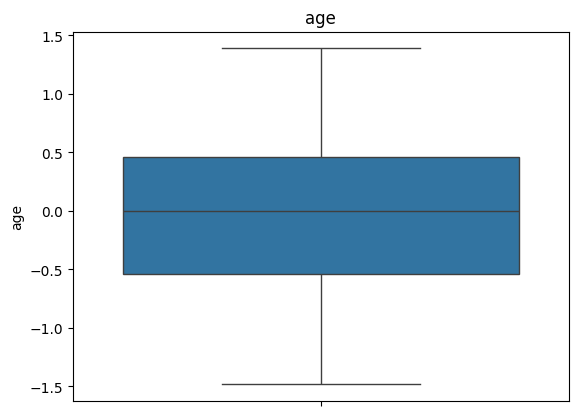

-0.8359579629750525


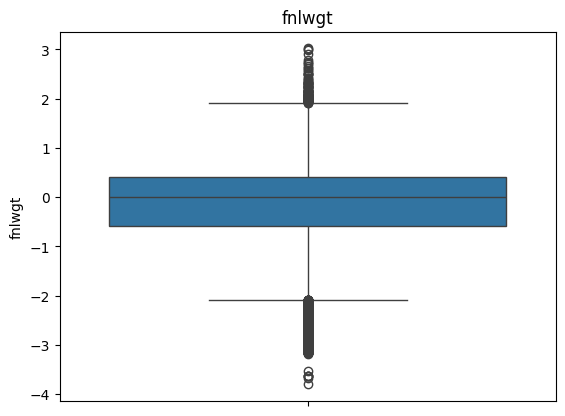

-0.31462587312851137


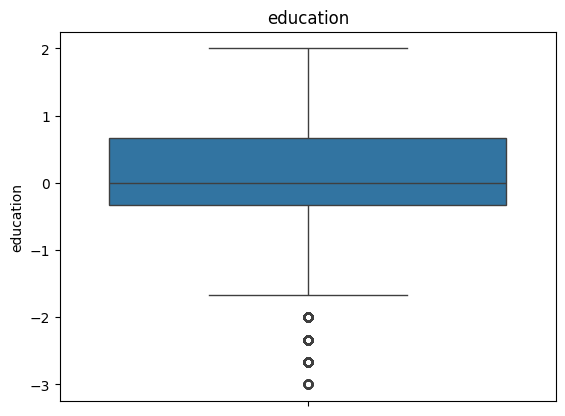

-1.7323446147284678


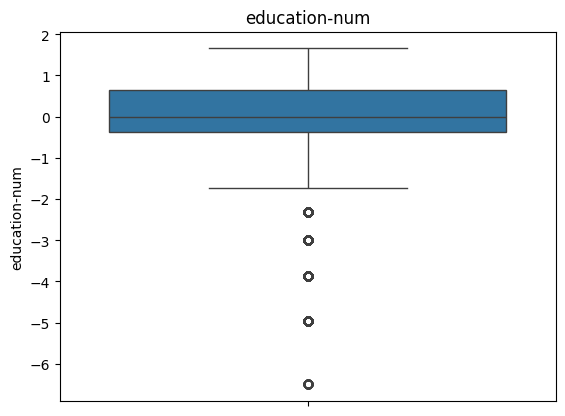

0.507699504532792


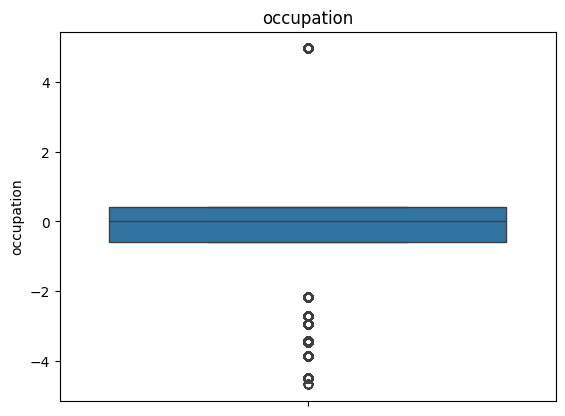

-0.7163476199372977


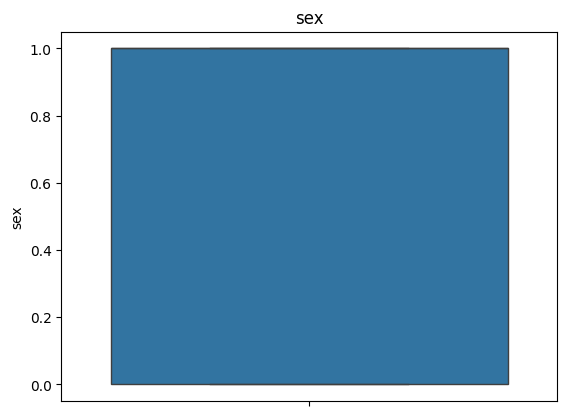

3.1108313972131847


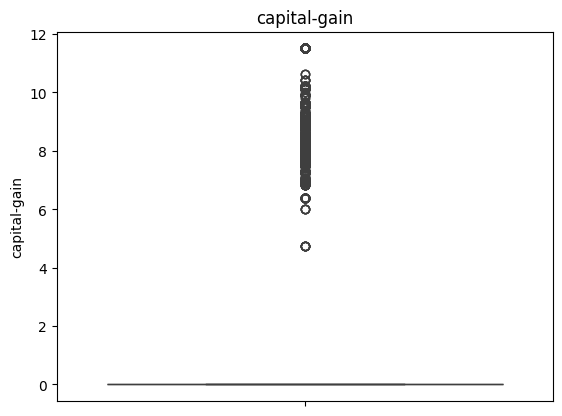

4.29949377385265


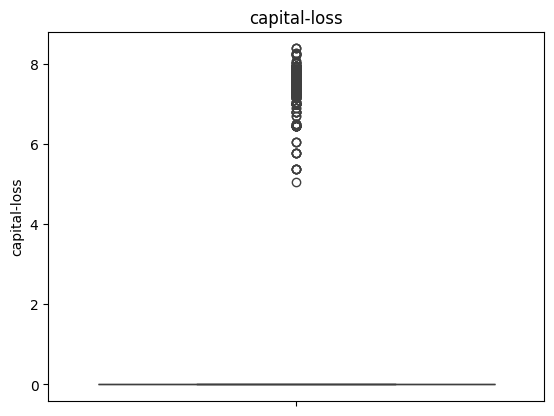

0.2022214460195844


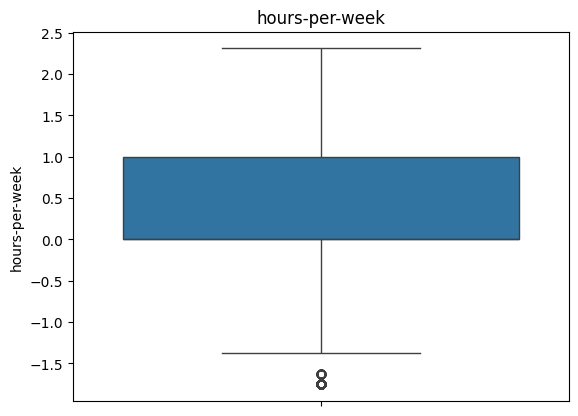

-3.0722314692333295


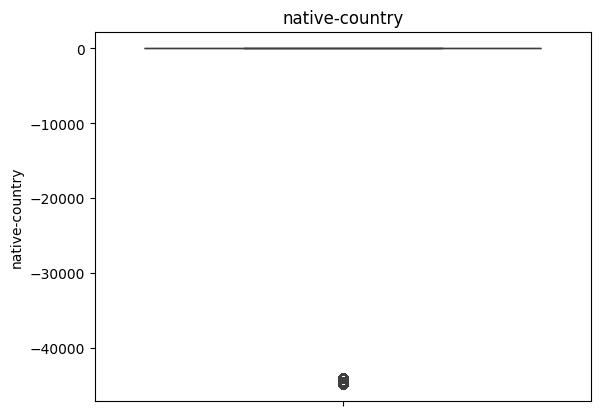

3.670339316639233


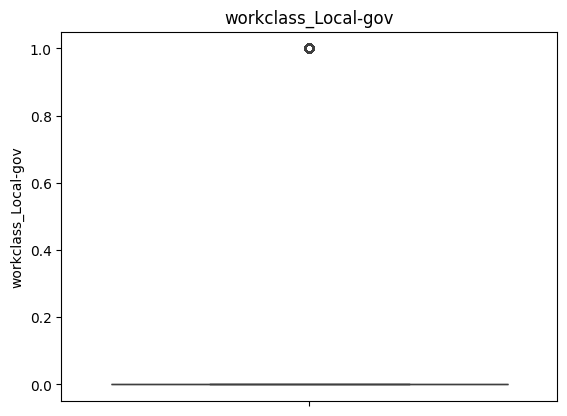

73.59800734345714


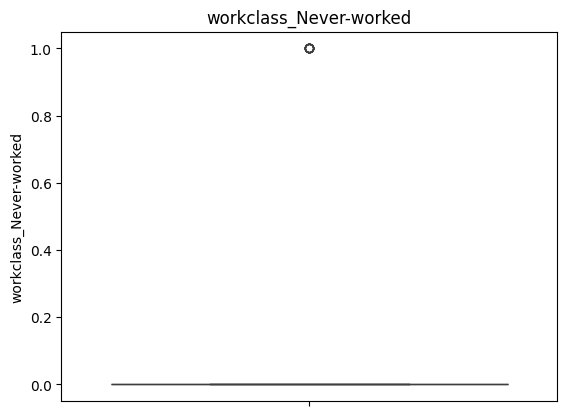

-1.2455955108435404


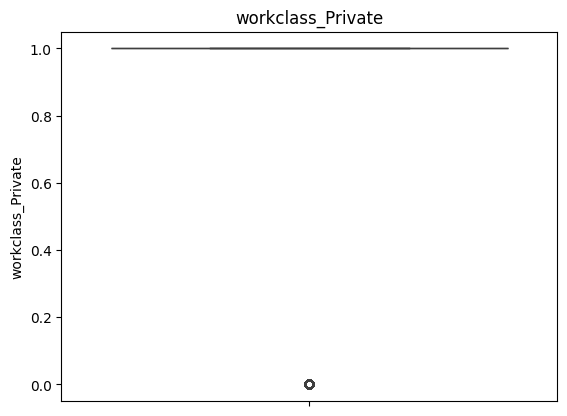

5.2028222604054655


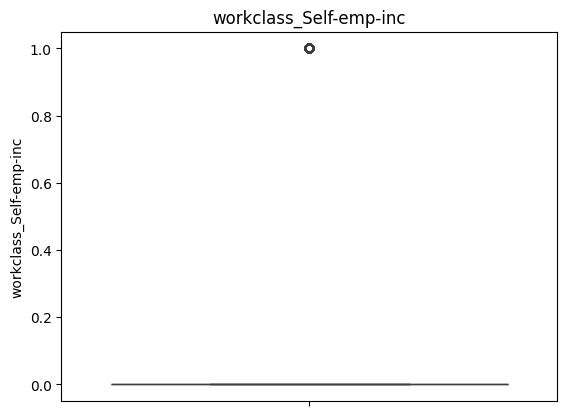

3.232322485039667


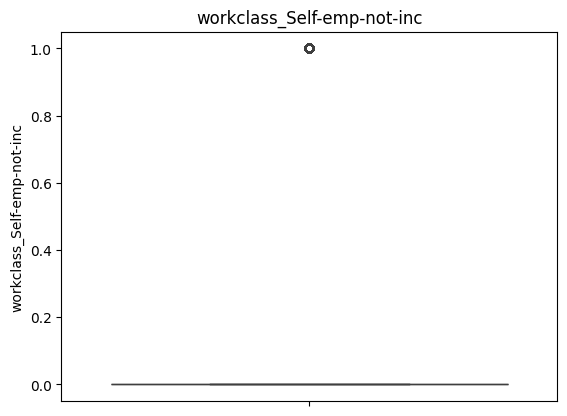

4.800036746551224


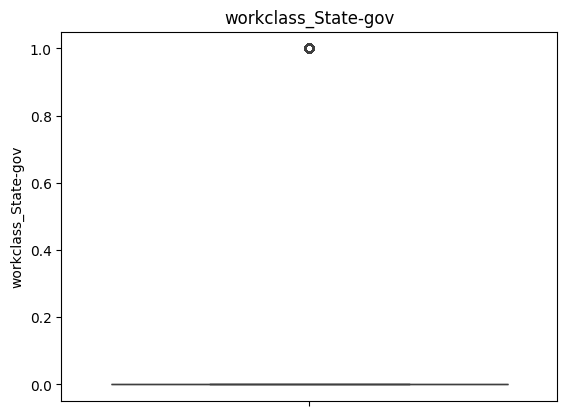

52.0272383191683


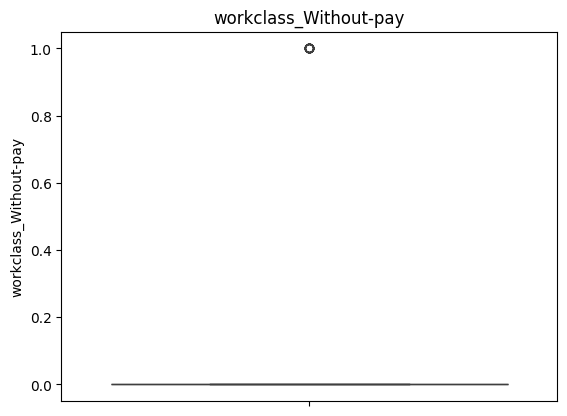

36.2670356717973


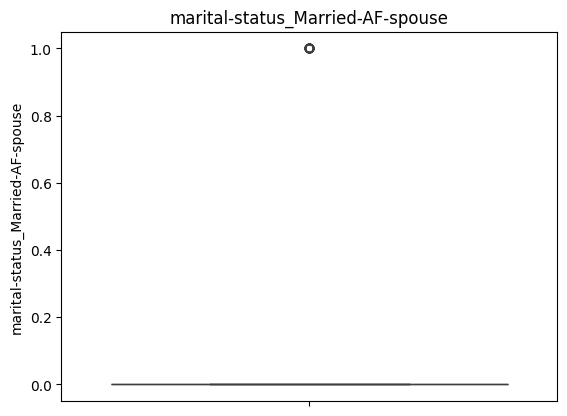

0.16673559238843774


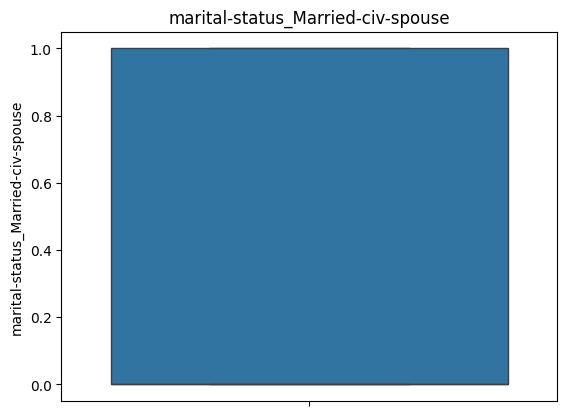

8.649109637382278


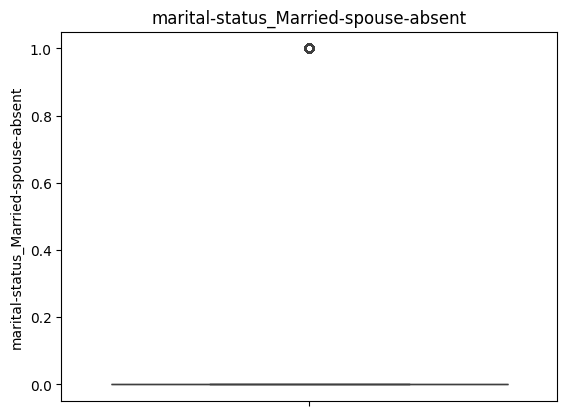

0.7256073585561202


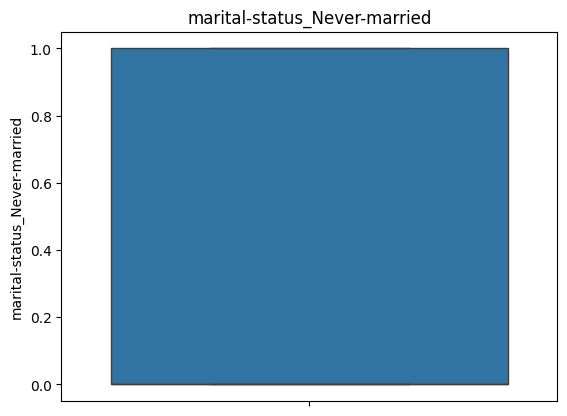

5.377043312664178


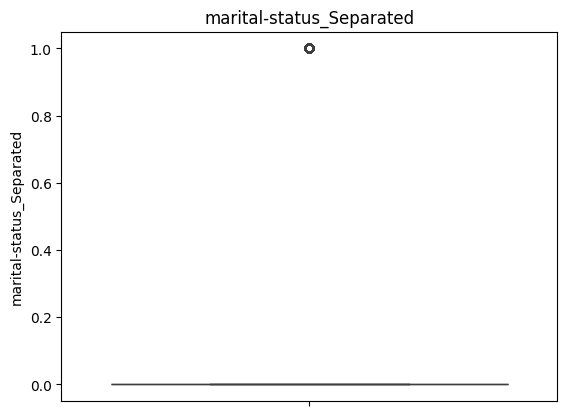

5.400402903633853


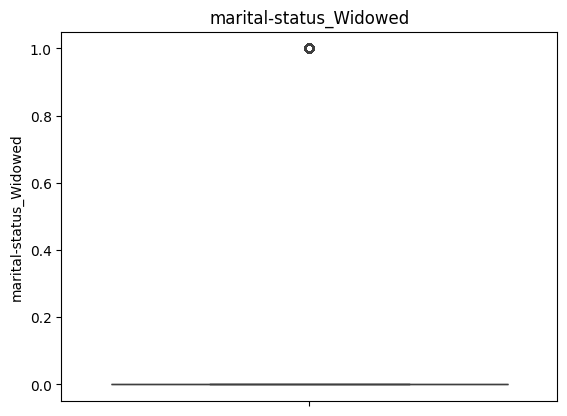

1.1095041046621625


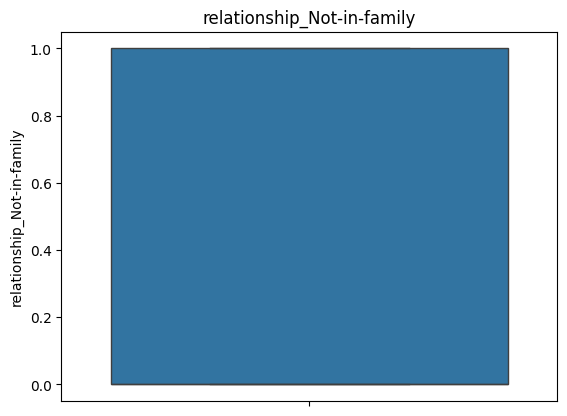

5.424032137407895


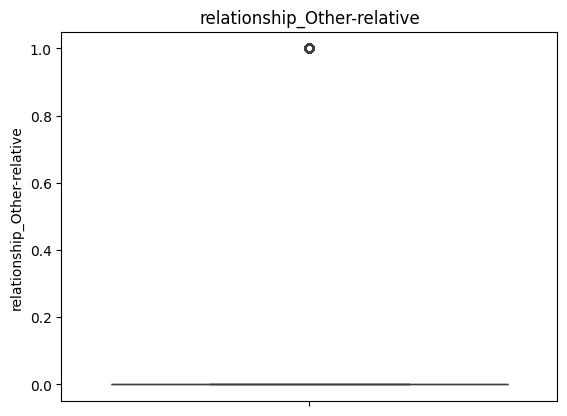

1.9072804976980293


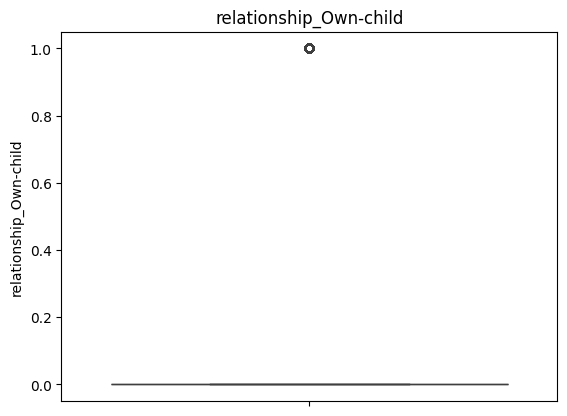

2.5757911502825497


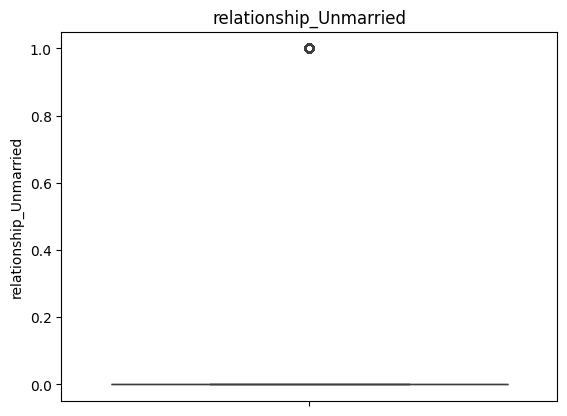

4.239736206953941


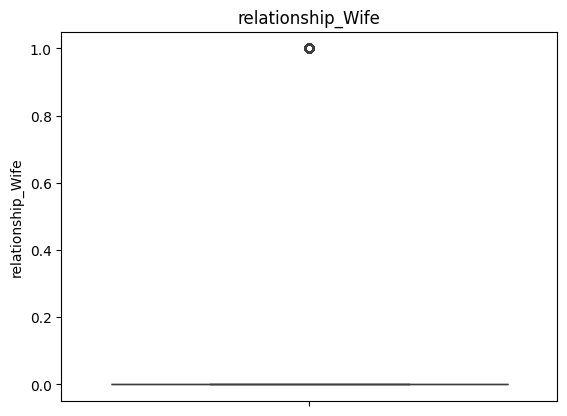

5.402361634459779


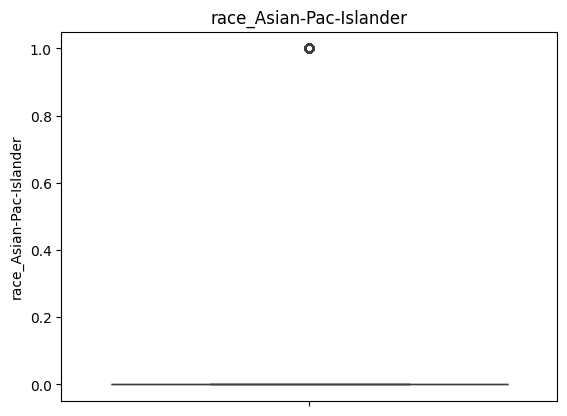

2.7421879434139984


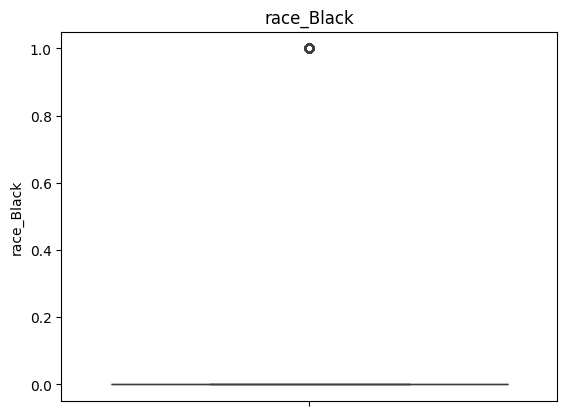

10.823520889889371


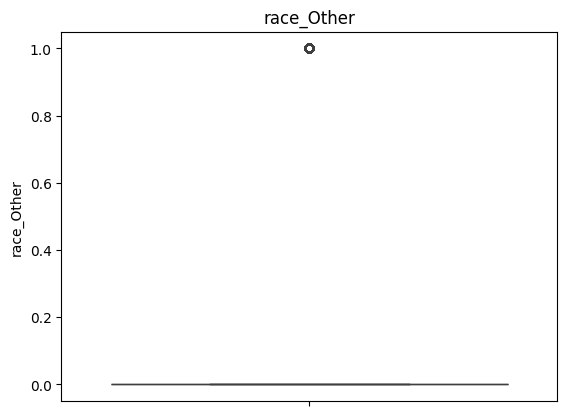

-2.0154100392919947


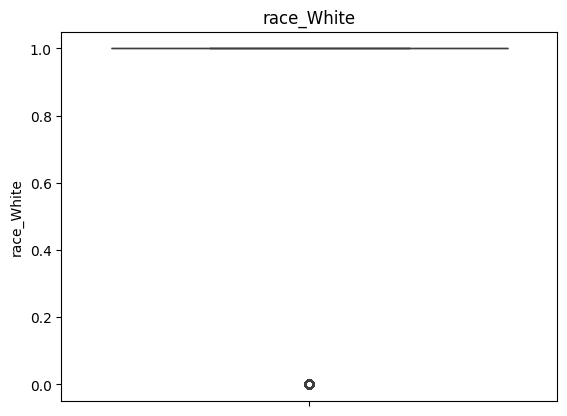

In [109]:
for i in scaled_df.select_dtypes('number').columns:
    sns.boxplot(scaled_df[i])
    plt.title(i)
    print(scaled_df[i].skew())
    plt.show()

####Elbow Method

In [110]:
from sklearn.cluster import KMeans
wcss=[]

for i in range(2,11):

    km=KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(scaled_df)

    wcss.append(km.inertia_)

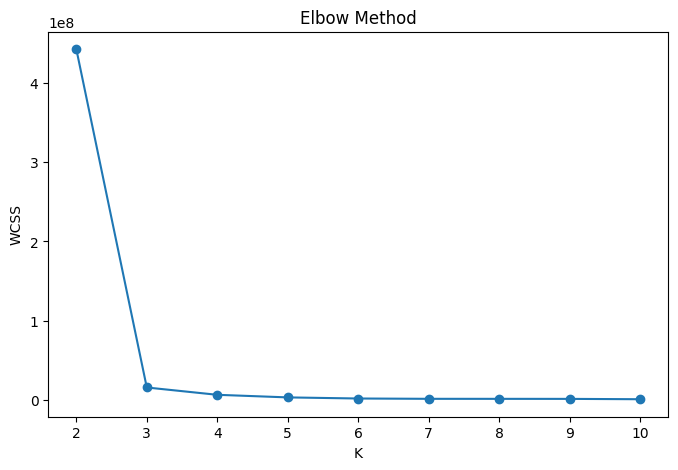

In [111]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11),wcss,marker='o')

plt.xlabel("K")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [112]:
#KMeans
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(scaled_df)

#scaled_df["KMeans_Cluster"] = kmeans_labels

####Silhouette Score

In [113]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_df,
    kmeans_labels
)

print(score)

0.9933513569377461


In [114]:
df = df.loc[scaled_df.index]
df["KMeans_Cluster"] = kmeans_labels

In [115]:
df

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,KMeans_Cluster
0,3.688879,11.258253,12.0,2.639057,5328,1,7.684784,0.0,3.713572,44869,...,1,0,0,0,0,0,0,0,1,0
1,3.931826,11.330348,12.0,2.639057,5770,1,0.000000,0.0,3.511545,44869,...,0,0,0,0,0,0,0,0,1,0
2,3.663562,12.281398,8.0,2.302585,1976,1,0.000000,0.0,3.713572,44869,...,1,0,0,0,0,0,0,0,1,0
3,3.988984,12.366157,6.0,2.079442,1976,1,0.000000,0.0,3.713572,44869,...,0,0,0,0,0,0,1,0,0,0
4,3.367296,12.732013,12.0,2.639057,10966,0,0.000000,0.0,3.713572,132,...,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,3.688879,12.280345,12.0,2.639057,10966,0,0.000000,0.0,3.610918,44869,...,1,0,0,0,0,0,0,0,1,0
48838,4.174387,12.680454,8.0,2.302585,10966,1,0.000000,0.0,3.713572,44869,...,0,1,0,0,0,0,1,0,0,0
48839,3.663562,12.834639,12.0,2.639057,10966,1,0.000000,0.0,3.931826,44869,...,0,0,0,0,0,0,0,0,1,0
48840,3.806662,11.337286,12.0,2.639057,5328,1,8.604471,0.0,3.713572,44869,...,0,0,1,0,0,1,0,0,0,0


In [116]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,44824
1,3049
2,901


In [117]:
df.groupby("KMeans_Cluster").mean(numeric_only=True)

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,3.620961,11.968639,9.173746,2.386988,5882.642424,0.667767,0.741554,0.357302,3.731612,44869.000000,...,0.031323,0.260441,0.025567,0.158933,0.103471,0.046984,0.013497,0.098362,0.004908,0.873126
1,3.645471,12.048177,8.880289,2.320593,6036.057724,0.650377,0.665607,0.327885,3.723702,122.844867,...,0.031814,0.234831,0.077730,0.115776,0.121023,0.064611,0.298786,0.088554,0.040997,0.569367
2,3.506376,12.471461,5.007769,1.817794,4538.504994,0.771365,0.349272,0.140744,3.715531,906.000000,...,0.018868,0.185350,0.136515,0.088790,0.130966,0.031077,0.001110,0.005549,0.067703,0.914539


In [118]:
df.groupby("KMeans_Cluster")["occupation"].value_counts()

KMeans_Cluster  occupation
0               10966         10060
                5770           5432
                5790           5316
                5328           4977
                5231           4925
                4654           4099
                2872           2501
                2238           2114
                1976           1766
                1382           1295
                1428           1268
                943             896
                233             160
                15               15
1               10966           774
                4654            411
                5790            334
                5770            313
                5328            299
                5231            252
                2872            238
                1976            116
                2238             94
                1382             80
                233              49
                1428             48
                943              41
2               4654            139
                5790            134
                2872            130
                10966           112
                1428            110
                1976             94
                5328             49
                5231             47
                2238             28
                233              23
                5770             23
                1382              7
                943               5
Name: count, dtype: int64

In [119]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [120]:
#Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
#sample_df = scaled_df.sample(n=5000, random_state=42)

#agg = AgglomerativeClustering(
 #   n_clusters=3,
  #  linkage='ward'
#)

#agg_labels = agg.fit_predict(sample_df)
#df["Agg_Cluster"] = agg_labels

In [121]:
sample_df = scaled_df.sample(n=5000, random_state=42)

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(sample_df)

sample_df["Agg_Cluster"] = agg_labels

In [122]:
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage


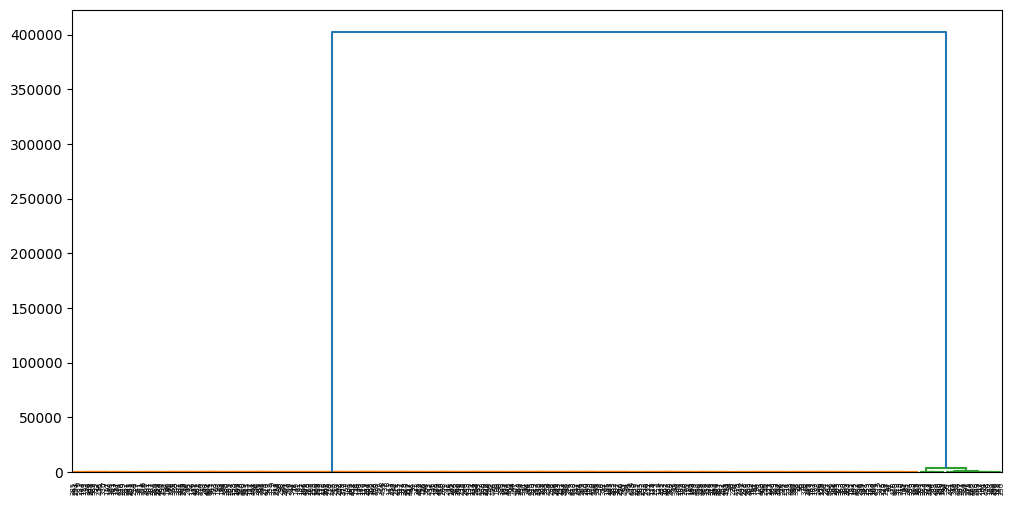

In [123]:
#Dendrogram

plt.figure(figsize=(12,6))

linked = linkage(
    scaled_df.sample(500, random_state=42),
    method='ward'
)

dendrogram(linked)

plt.show()

####pca

In [124]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = kmeans_labels

In [125]:
#explained varience
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_)

[9.99999849e-01 5.23565248e-08]
[9.99999849e-01 5.23565248e-08]


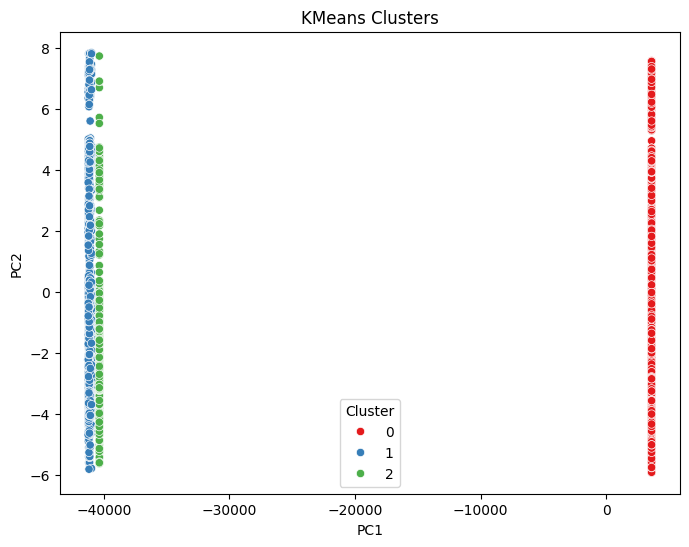

In [126]:
#pca plot(kmeans)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set1"
)

plt.title("KMeans Clusters")

plt.show()

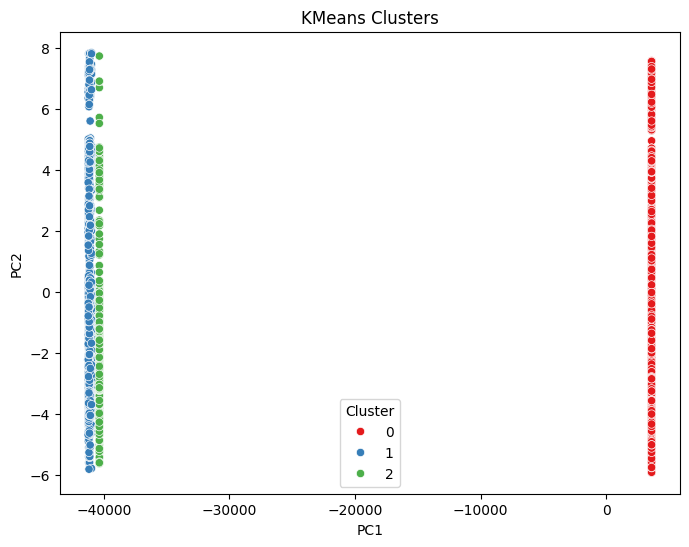

In [127]:
#PCA Plot (Agglomerative)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set1"
)

plt.title("KMeans Clusters")

plt.show()

In [128]:
#Cluster Interpretation

cluster_summary = df.groupby("KMeans_Cluster").mean()

cluster_summary

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,3.620961,11.968639,9.173746,2.386988,5882.642424,0.667767,0.741554,0.357302,3.731612,44869.000000,...,0.031323,0.260441,0.025567,0.158933,0.103471,0.046984,0.013497,0.098362,0.004908,0.873126
1,3.645471,12.048177,8.880289,2.320593,6036.057724,0.650377,0.665607,0.327885,3.723702,122.844867,...,0.031814,0.234831,0.077730,0.115776,0.121023,0.064611,0.298786,0.088554,0.040997,0.569367
2,3.506376,12.471461,5.007769,1.817794,4538.504994,0.771365,0.349272,0.140744,3.715531,906.000000,...,0.018868,0.185350,0.136515,0.088790,0.130966,0.031077,0.001110,0.005549,0.067703,0.914539


In [129]:
scaled_df.shape

(48774, 32)

In [130]:
scaled_df.head()

,age,fnlwgt,education,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,native-country,...,marital-status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,0.101792,-1.182338,1.000000,0.919188,0.000000,1,7.684784,0.0,0.000000,0.0,...,0,1,0,0,0,0,0,0,0,1
1,0.583918,-1.079893,1.000000,0.919188,0.389085,1,0.000000,0.0,-1.755695,0.0,...,0,0,0,0,0,0,0,0,0,1
2,0.051548,0.271511,-0.333333,-0.363274,-2.950704,1,0.000000,0.0,0.000000,0.0,...,0,1,0,0,0,0,0,0,0,1
3,0.697349,0.391950,-1.000000,-1.213785,-2.950704,1,0.000000,0.0,0.000000,0.0,...,0,0,0,0,0,0,0,1,0,0
4,-0.536391,0.911818,1.000000,0.919188,4.963028,0,0.000000,0.0,0.000000,-44737.0,...,0,0,0,0,0,1,0,1,0,0


In [131]:
scaled_df.columns

Index(['age', 'fnlwgt', 'education', 'education-num', 'occupation', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private',
       'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc',
       'workclass_State-gov', 'workclass_Without-pay',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'relationship_Not-in-family', 'relationship_Other-relative',
       'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White'],
      dtype='object')

In [132]:
#dbscan

from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

db_labels = dbscan.fit_predict(scaled_df)

In [133]:
df["DBSCAN_Cluster"] = db_labels

In [134]:
import numpy as np

print("Clusters :", len(np.unique(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise Points :", list(db_labels).count(-1))

Clusters : 28
Noise Points : 7209


In [135]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["DBSCAN"] = db_labels

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


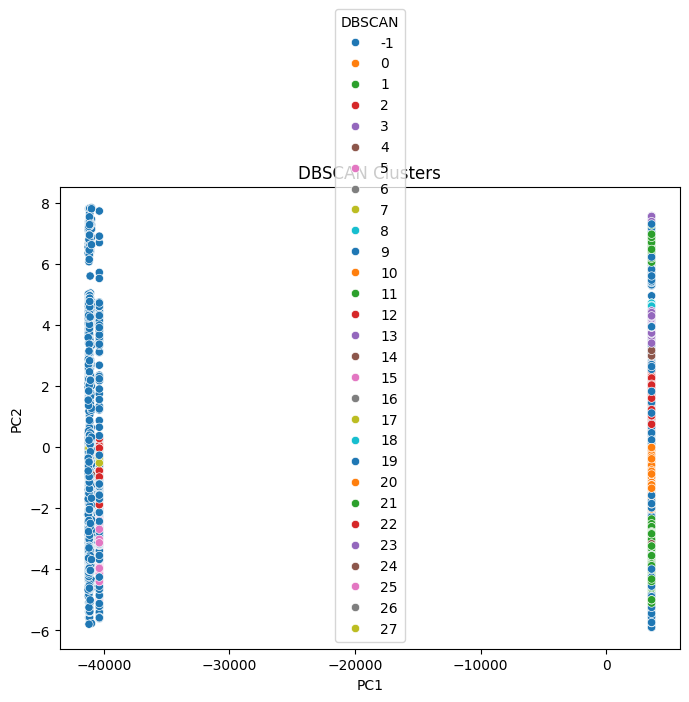

In [136]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    data=pca_df,
    palette="tab10",
    legend="full"
)

plt.title("DBSCAN Clusters")

plt.show()